In [1]:
!pip install pandas
!pip install openpyxl


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing Dataset

Python needs lots of codes to read long datasets with pandas library we can read all of them with one code.

So based on our project we load efficiency dataset from our excel file to access the required data.

After loading, we check the basic structure and gain some basic information about the columns and rows.

**Result:** The dataset contains 768 rows and 10 columns.

In [2]:
import pandas as pd

#loading excel file into dataframe
df = pd.read_excel('ENB2012_data.xlsx')

print("(the number of columns, the number of rows): ")

#show the number of rows and columns
print(df.shape)

(the number of columns, the number of rows): 
(768, 10)


## Rename Columns

Our dataset originally uses x1 ,x2 etc.

To find out each parameter refers to, we rename them.

So this makes our analysis more professional and when ever we use column we exactly know what it refers to .

In [3]:
df.columns=['X1_Relative_Compactness', 'X2_Surface_Area', 'X3_Wall_Area', 
              'X4_Roof_Area', 'X5_Overall_Height', 'X6_Orientation', 
              'X7_Glazing_Area', 'X8_Glazing_Dist', 'Y1_Heating_Load', 'Y2_Cooling_Load']

print("the first 5 row of data with new names:")

#showing first 5 rows
print(df.head())

the first 5 row of data with new names:
   X1_Relative_Compactness  X2_Surface_Area  X3_Wall_Area  X4_Roof_Area  \
0                     0.98            514.5         294.0        110.25   
1                     0.98            514.5         294.0        110.25   
2                     0.98            514.5         294.0        110.25   
3                     0.98            514.5         294.0        110.25   
4                     0.90            563.5         318.5        122.50   

   X5_Overall_Height  X6_Orientation  X7_Glazing_Area  X8_Glazing_Dist  \
0                7.0               2              0.0                0   
1                7.0               3              0.0                0   
2                7.0               4              0.0                0   
3                7.0               5              0.0                0   
4                7.0               2              0.0                0   

   Y1_Heating_Load  Y2_Cooling_Load  
0            15.55        

In [4]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Histogram for Target Variables

In this section, we draw a histogram to visualize the distribution of our target variables(heating/cooling load).

A histogram seprate and group dataset in specific intervals. Moreover it also shows how many samples fall into each range.

We also customize the diagram with some details such as color, fontsize to make it clear.

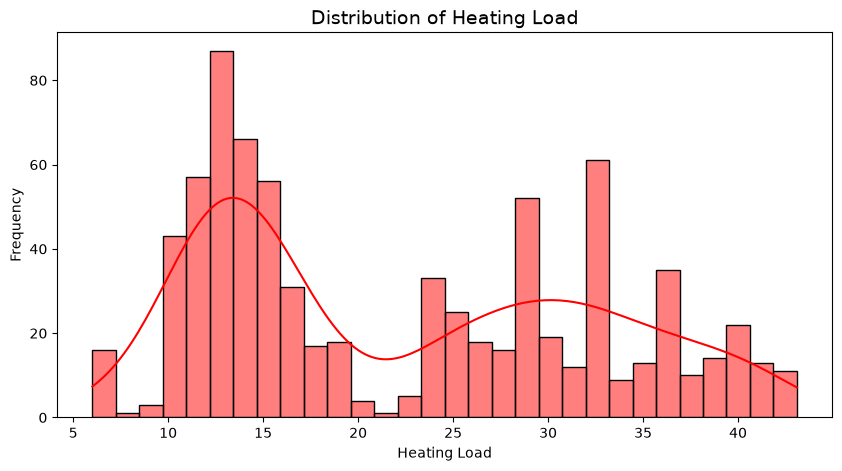

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

#diagram size
plt.figure(figsize=(10, 5))
sns.histplot(df['Y1_Heating_Load'], bins=30, kde=True, color='red')
plt.title('Distribution of Heating Load', fontsize=14)
plt.xlabel('Heating Load')
plt.ylabel('Frequency')
plt.show()

## Correlation Matrix

In this section, we draw a correlation matrix to examine the relationship between all features and the target variables (Heating Load and Cooling Load).

This heatmap helps us identify which features have the strongest impact and which are highly correlated, while also avoiding multicollinearity in our models.

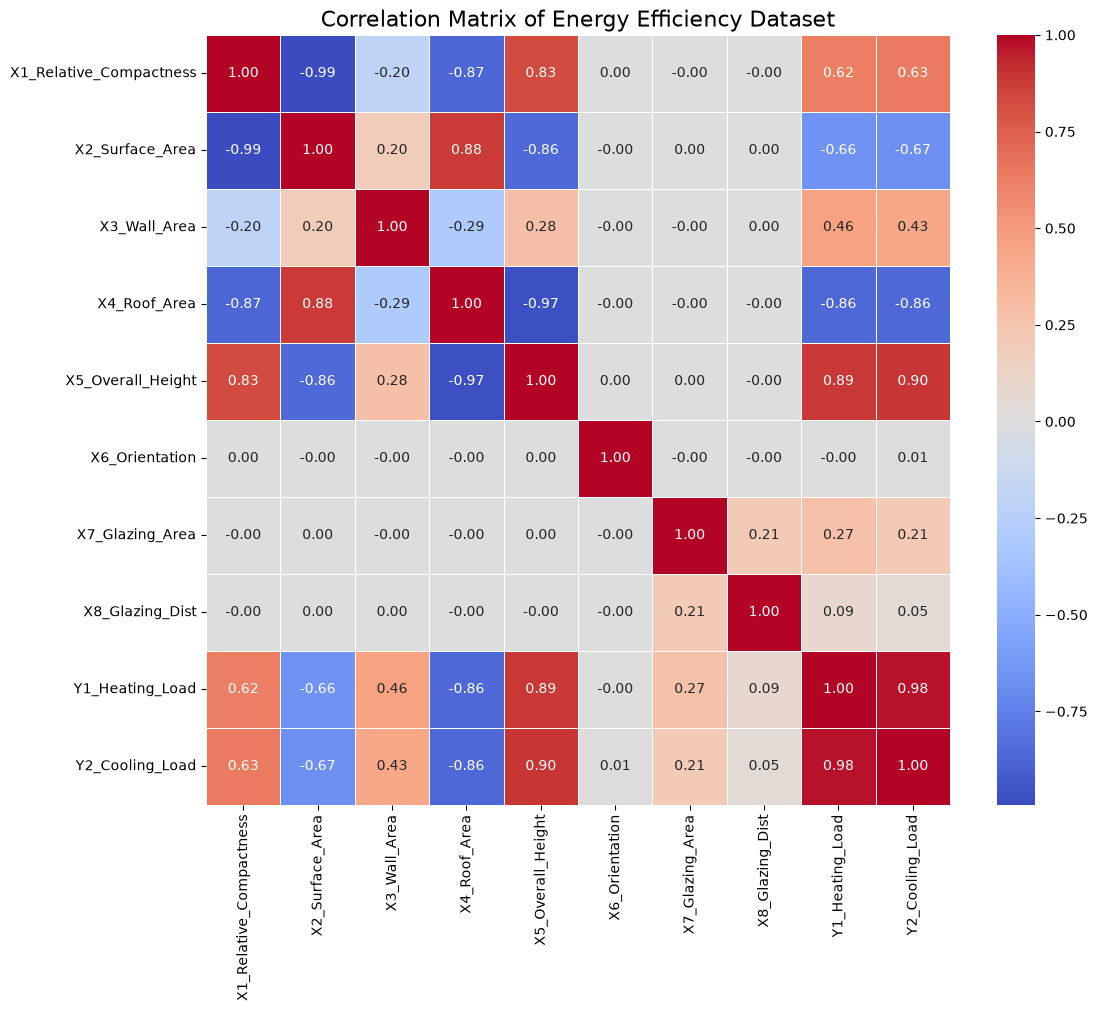

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

# Draw a colorful heatmap showing correlation coefficients between each pair of features
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Energy Efficiency Dataset', fontsize=16)
plt.show()

## Correlation values for target variables

In this section, We list our correlation values into two ordered groups (cooling and heating load) to define how much each variable has correlation with our targets.

In [7]:
#
corr_heating = df.corr()['Y1_Heating_Load'].sort_values(ascending=False)
print("=== Correlation with Heating Load ===")
print(corr_heating)

print("\n" + "="*50 + "\n")

corr_cooling = df.corr()['Y2_Cooling_Load'].sort_values(ascending=False)
print("=== Correlation with Cooling Load ===")
print(corr_cooling)

=== Correlation with Heating Load ===
Y1_Heating_Load            1.000000
Y2_Cooling_Load            0.975862
X5_Overall_Height          0.889430
X1_Relative_Compactness    0.622272
X3_Wall_Area               0.455671
X7_Glazing_Area            0.269842
X8_Glazing_Dist            0.087368
X6_Orientation            -0.002587
X2_Surface_Area           -0.658120
X4_Roof_Area              -0.861828
Name: Y1_Heating_Load, dtype: float64


=== Correlation with Cooling Load ===
Y2_Cooling_Load            1.000000
Y1_Heating_Load            0.975862
X5_Overall_Height          0.895785
X1_Relative_Compactness    0.634339
X3_Wall_Area               0.427117
X7_Glazing_Area            0.207505
X8_Glazing_Dist            0.050525
X6_Orientation             0.014290
X2_Surface_Area           -0.672999
X4_Roof_Area              -0.862547
Name: Y2_Cooling_Load, dtype: float64


## Scatter plots for key features

In this section , We visualize scatter plots to find out the relation between target variables and key features .
We focus on the relation between height or surface area and heating/cooling load .
This diagram also helps us define nature of relationships(linear,non-linear,etc) and moreover guide our regression model.

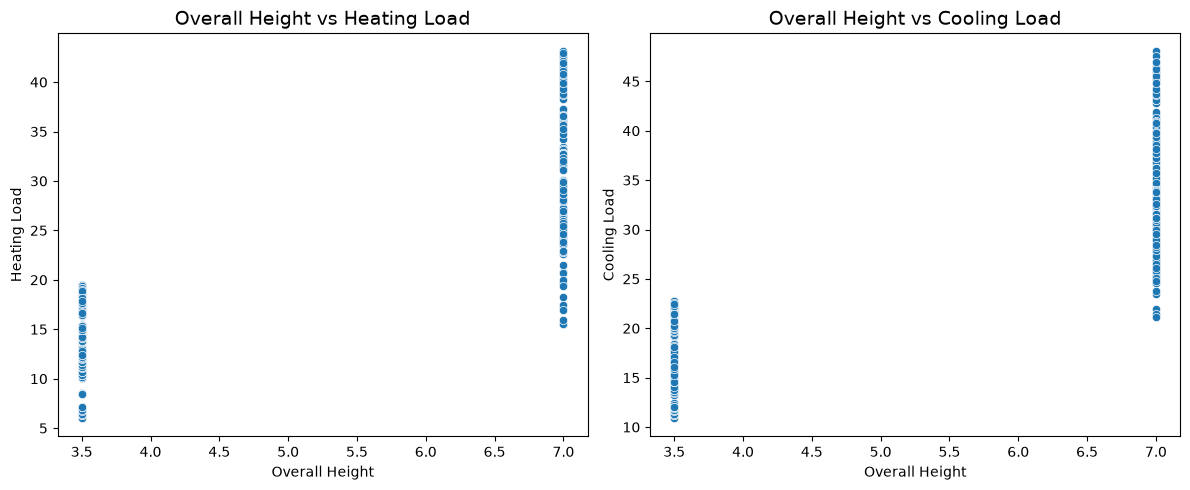

In [8]:
plt.figure(figsize=(12, 5))

#
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['X5_Overall_Height'], y=df['Y1_Heating_Load'])
plt.title('Overall Height vs Heating Load', fontsize=14)
plt.xlabel('Overall Height')
plt.ylabel('Heating Load')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df['X5_Overall_Height'], y=df['Y2_Cooling_Load'])
plt.title('Overall Height vs Cooling Load', fontsize=14)
plt.xlabel('Overall Height')
plt.ylabel('Cooling Load')

plt.tight_layout()
plt.show()

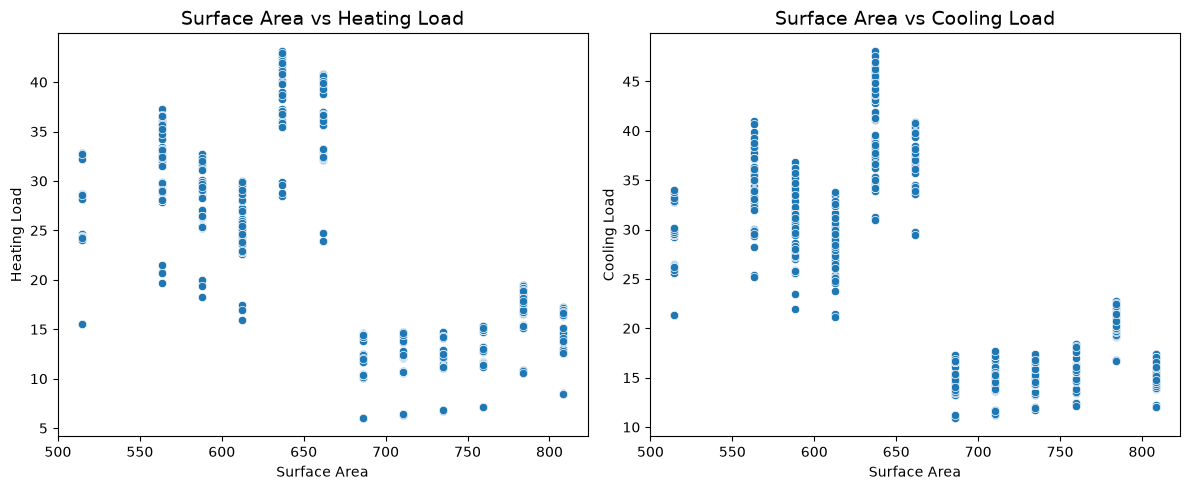

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=df['X2_Surface_Area'], y=df['Y1_Heating_Load'])
plt.title('Surface Area vs Heating Load', fontsize=14)
plt.xlabel('Surface Area')
plt.ylabel('Heating Load')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df['X2_Surface_Area'], y=df['Y2_Cooling_Load'])
plt.title('Surface Area vs Cooling Load', fontsize=14)
plt.xlabel('Surface Area')
plt.ylabel('Cooling Load')

plt.tight_layout()
plt.show()